In [3]:
# Step-1 : import Libraries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [4]:
# Step-2 : Load, and First 5 rows of Dataset

df = pd.read_csv("C:\Data Science Projects @\Online retail Datase\Online_Retail_Data.csv", encoding='latin1') # Here we use "encoding='latin1'" 
df.head()                                                     # to solve UnicodeDecodeError: 'utf-8'

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\PC\AppData\Local\Temp\ipykernel_6728\3979095089.py:3: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\Data Science Projects @\Online retail Datase\Online_Retail_Data.csv", encoding='latin1') # Here we use "encoding='latin1'"


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France


In [6]:
# Step-3 : Exploratory Data Analysis (EDA)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.shape

(541909, 8)

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [11]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [12]:
# Here columns are renamed for easy understanding.
df.rename(columns = {'InvoiceNo':'order_number', 'StockCode':'Product_ID', 'Description':'Product_name', 
                     'InvoiceDate':'purchased_date/time', 'Country':'cust_country'},
         inplace=True)
df.head()

,order_number,Product_ID,Product_name,Quantity,purchased_date/time,UnitPrice,CustomerID,cust_country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [13]:
df.dtypes

order_number            object
Product_ID              object
Product_name            object
Quantity                 int64
purchased_date/time     object
UnitPrice              float64
CustomerID             float64
cust_country            object
dtype: object

In [14]:
# Step-4 : Data cleaning

df.isnull().sum()

order_number                0
Product_ID                  0
Product_name             1454
Quantity                    0
purchased_date/time         0
UnitPrice                   0
CustomerID             135080
cust_country                0
dtype: int64

In [15]:
df = df.dropna(subset=['CustomerID'])   # Here we remove Null/Missing values

In [16]:
df.isnull().sum()

order_number           0
Product_ID             0
Product_name           0
Quantity               0
purchased_date/time    0
UnitPrice              0
CustomerID             0
cust_country           0
dtype: int64

In [17]:
df.duplicated().sum()

5225

In [18]:
df.drop_duplicates()

,order_number,Product_ID,Product_name,Quantity,purchased_date/time,UnitPrice,CustomerID,cust_country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France


In [19]:
df.shape

(406829, 8)

In [20]:
# Now we convert data type of column "purchased_date/time" [object>>datetime]

df["purchased_date/time"] = pd.to_datetime(df["purchased_date/time"], dayfirst = True)

C:\Users\PC\AppData\Local\Temp\ipykernel_6728\3296819759.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["purchased_date/time"] = pd.to_datetime(df["purchased_date/time"], dayfirst = True)


In [21]:
# convert CustomerID 'float' to 'int'

df['CustomerID'] = df['CustomerID'].astype(int)

C:\Users\PC\AppData\Local\Temp\ipykernel_6728\3302295184.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CustomerID'] = df['CustomerID'].astype(int)


In [22]:
df.dtypes

order_number                   object
Product_ID                     object
Product_name                   object
Quantity                        int64
purchased_date/time    datetime64[ns]
UnitPrice                     float64
CustomerID                      int32
cust_country                   object
dtype: object

In [23]:
# Here We removed Negative Quantity
df = df[df['Quantity'] >0]

In [24]:
df = df[df['UnitPrice'] >0]
df.head()

,order_number,Product_ID,Product_name,Quantity,purchased_date/time,UnitPrice,CustomerID,cust_country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [25]:
# Now we create a new feature 'Total_price' column.

df['Total_price'] = df['Quantity'] * df['UnitPrice']
df.head()

,order_number,Product_ID,Product_name,Quantity,purchased_date/time,UnitPrice,CustomerID,cust_country,Total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [26]:
# Step-5 : Now let's prepare data for ML

## Let's find customer's Total spending ##
df.groupby('CustomerID')['Total_price'].sum()

CustomerID
12346    77183.60
12347     4310.00
12348     1797.24
12349     1757.55
12350      334.40
           ...   
18280      180.60
18281       80.82
18282      178.05
18283     2094.88
18287     1837.28
Name: Total_price, Length: 4338, dtype: float64

In [27]:
## Now let's find Count of orders ##
df.groupby('CustomerID')['order_number'].count()

CustomerID
12346      1
12347    182
12348     31
12349     73
12350     17
        ... 
18280     10
18281      7
18282     12
18283    756
18287     70
Name: order_number, Length: 4338, dtype: int64

In [28]:
### combing both Sum and count ###
customer_data = df.groupby('CustomerID').agg({'Total_price':'sum','order_number':'count'})
customer_data

,Total_price,order_number
CustomerID,,
12346,77183.60,1
12347,4310.00,182
12348,1797.24,31
12349,1757.55,73
12350,334.40,17
...,...,...
18280,180.60,10
18281,80.82,7
18282,178.05,12


In [29]:
customer_data.rename(columns={"Total_price":"Total_spending", "order_number":"Total_orders"}, inplace=True)
customer_data

,Total_spending,Total_orders
CustomerID,,
12346,77183.60,1
12347,4310.00,182
12348,1797.24,31
12349,1757.55,73
12350,334.40,17
...,...,...
18280,180.60,10
18281,80.82,7
18282,178.05,12


In [30]:
# Step-6 : Model Building "Customer Segmentation Model (Clustering)"

### Feature selection ###
x = customer_data[['Total_spending','Total_orders']]

In [31]:
# Now lets standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_data = scaler.fit_transform(x)
X_scaled_data

array([[ 8.35866818e+00, -3.96577702e-01],
       [ 2.50966264e-01,  3.94648958e-01],
       [-2.85960063e-02, -2.65435162e-01],
       ...,
       [-2.08742313e-01, -3.48492104e-01],
       [ 4.51854273e-03,  2.90384290e+00],
       [-2.41412739e-02, -9.49498596e-02]])

In [32]:
from sklearn.cluster import KMeans
# Giving data to model for clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [33]:
# Applying Model
customer_data['segments']= kmeans.fit_predict(X_scaled_data)
customer_data.head()

,Total_spending,Total_orders,segments
CustomerID,,,
12346,77183.60,1,0
12347,4310.00,182,0
12348,1797.24,31,0
12349,1757.55,73,0
12350,334.40,17,0


In [34]:
# Grouping Customer data By segments in which it shows avg spending + orders

customer_data.groupby('segments').mean().round(2)

,Total_spending,Total_orders
segments,,
0,1712.81,84.28
1,190863.46,826.83
2,59437.62,4717.83


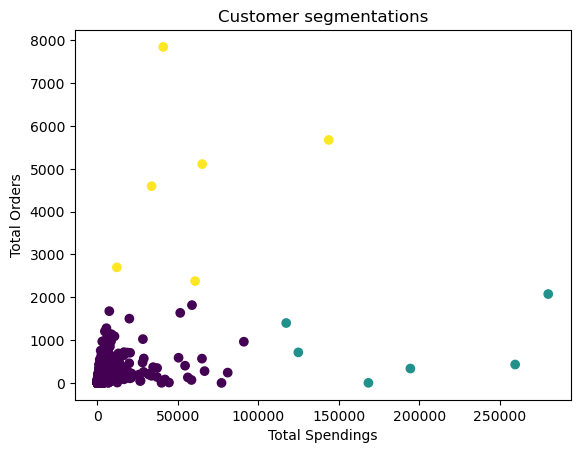

In [35]:
# Visualization 
plt.scatter(customer_data['Total_spending'],
            customer_data['Total_orders'],
            c = customer_data['segments']
)
plt.xlabel("Total Spendings")
plt.ylabel("Total Orders")
plt.title("Customer segmentations")

plt.show()

In [36]:
# Step-7 Segment Summary 
customer_data.groupby('segments').agg({"Total_spending":'mean', "Total_orders":'mean'}).round(2)
customer_data

,Total_spending,Total_orders,segments
CustomerID,,,
12346,77183.60,1,0
12347,4310.00,182,0
12348,1797.24,31,0
12349,1757.55,73,0
12350,334.40,17,0
...,...,...,...
18280,180.60,10,0
18281,80.82,7,0
18282,178.05,12,0


In [37]:
customer_data['segments'].value_counts()

segments
0    4326
1       6
2       6
Name: count, dtype: int64

In [38]:
Segment_map = {
    0:'High Value',
    1:'Medium value',
    2:'Low Value'}

customer_data['segments']= customer_data['segments'].map(Segment_map)

In [39]:
# Here We lable the value criteria instead of using numbers
customer_data['segments'].value_counts()

segments
High Value      4326
Medium value       6
Low Value          6
Name: count, dtype: int64

In [40]:
# Step-8 : Customer Retention Analysis

customer_data['Customer type'] = customer_data['Total_orders'].apply(
    lambda K: 'Repeat customer' if K>1 else 'One-time customer')

customer_data['Customer type'].value_counts()

Customer type
Repeat customer      4267
One-time customer      71
Name: count, dtype: int64

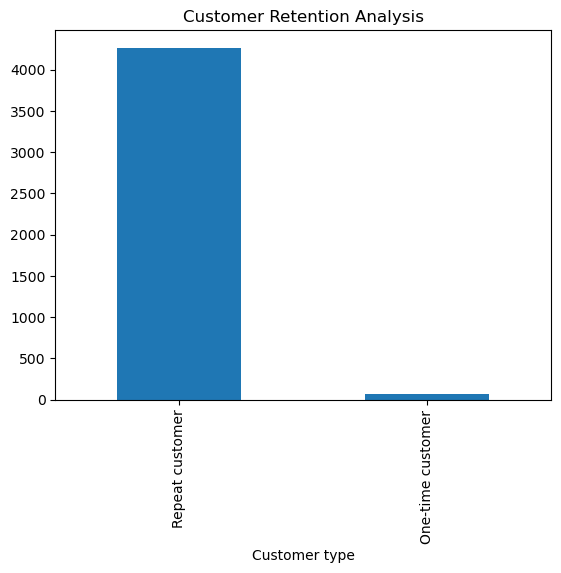

In [41]:
customer_data['Customer type'].value_counts().plot(kind='bar')
plt.title('Customer Retention Analysis')
plt.show()

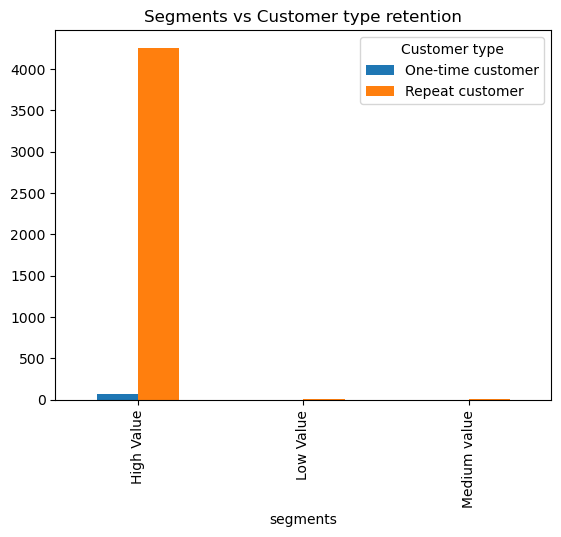

In [42]:
# Now visualize Segment vs Customer type retention 

pd.crosstab(customer_data['segments'],
             customer_data['Customer type']).plot(kind='bar')
plt.title('Segments vs Customer type retention')
plt.show()

In [43]:
# Let's convert this data into CSV file to create a Dashboard
customer_data.to_csv("Customer_segmentation_output.csv", index=False)

In [44]:
# Printing Final Insights
print('Total customers : ', len(customer_data))
print('-------------------------')
print(customer_data['segments'].value_counts())
print('-------------------------')
print(customer_data['Customer type'].value_counts())

Total customers :  4338
-------------------------
segments
High Value      4326
Medium value       6
Low Value          6
Name: count, dtype: int64
-------------------------
Customer type
Repeat customer      4267
One-time customer      71
Name: count, dtype: int64


In [48]:
df = pd.read_csv("Customer_segmentation_output.csv")
df.head()

,Total_spending,Total_orders,segments,Customer type
0,77183.60,1,High Value,One-time customer
1,4310.00,182,High Value,Repeat customer
2,1797.24,31,High Value,Repeat customer
3,1757.55,73,High Value,Repeat customer
4,334.40,17,High Value,Repeat customer


In [51]:
print(df.columns)

Index(['Total_spending', 'Total_orders', 'segments', 'Customer type'], dtype='object')


In [52]:
# Let's convert this data into CSV file
customer_data.to_csv("Customer_segmentation_output.csv", index=False)